In [1]:
import earthkit.data as ekd
from earthkit import transforms as ekt
import earthkit.plots as ekp
from earthkit import geo as ekg
from earthkit.geo import gisco
import pandas as pd
import numpy as np

In [2]:
%%capture
ds = ekd.from_source(
    "cds",
    "reanalysis-era5-single-levels",
    request = {
    "product_type": ["reanalysis"],
    "variable": ["total_cloud_cover"],
    "year": ["2026"],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "data_format": "grib",
    "download_format": "unarchived",
    "area": [45, -10, 36, 1]
}
).to_xarray()

In [3]:
ds

<xarray.Dataset> Size: 77MB
Dimensions:                  (forecast_reference_time: 5777, latitude: 37,
                              longitude: 45)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[us] 46kB 20...
  * latitude                 (latitude) float64 296B 45.0 44.75 ... 36.25 36.0
  * longitude                (longitude) float64 360B -10.0 -9.75 ... 0.75 1.0
Data variables:
    tcc                      (forecast_reference_time, latitude, longitude) float64 77MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

In [4]:
tcc_monthly_mean = ekt.temporal.monthly_mean(ds)

In [5]:
tcc_monthly_mean

<xarray.Dataset> Size: 107kB
Dimensions:                  (forecast_reference_time: 8, latitude: 37,
                              longitude: 45)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[us] 64B 202...
  * latitude                 (latitude) float64 296B 45.0 44.75 ... 36.25 36.0
  * longitude                (longitude) float64 360B -10.0 -9.75 ... 0.75 1.0
Data variables:
    tcc                      (forecast_reference_time, latitude, longitude) float64 107kB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

In [6]:
nuts3 = ekg.gisco.nuts_regions(level=3, year=2024).to_geopandas()
nuts3_pt = nuts3[nuts3["CNTR_CODE"] == "PT"]
nuts3_pt = nuts3_pt.iloc[:-2].reset_index(drop=True)

In [7]:
reduced_data_weighted = ekt.spatial.reduce(
    tcc_monthly_mean,
    nuts3_pt,
    weights="latitude",    
)

In [8]:
reduced_data_weighted

<xarray.Dataset> Size: 2kB
Dimensions:                  (forecast_reference_time: 8, index: 24)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[us] 64B 202...
  * index                    (index) int64 192B 0 1 2 3 4 5 ... 19 20 21 22 23
Data variables:
    tcc                      (index, forecast_reference_time) float64 2kB 0.8...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

In [9]:
title = """Total cloud cover (TCC) shows the fraction of the sky covered by clouds across all layers, ranging from 0 (clear)
to 1 (fully overcast). Lighter colors indicate less cloud cover, while darker colors indicate greater cloud cover."""

caption = """Data: ERA5 hourly data on single levels from 1940 to present | Source: CDS | DOI: 10.24381/cds.adbb2d47 | Created by: Bernadett Piros"""

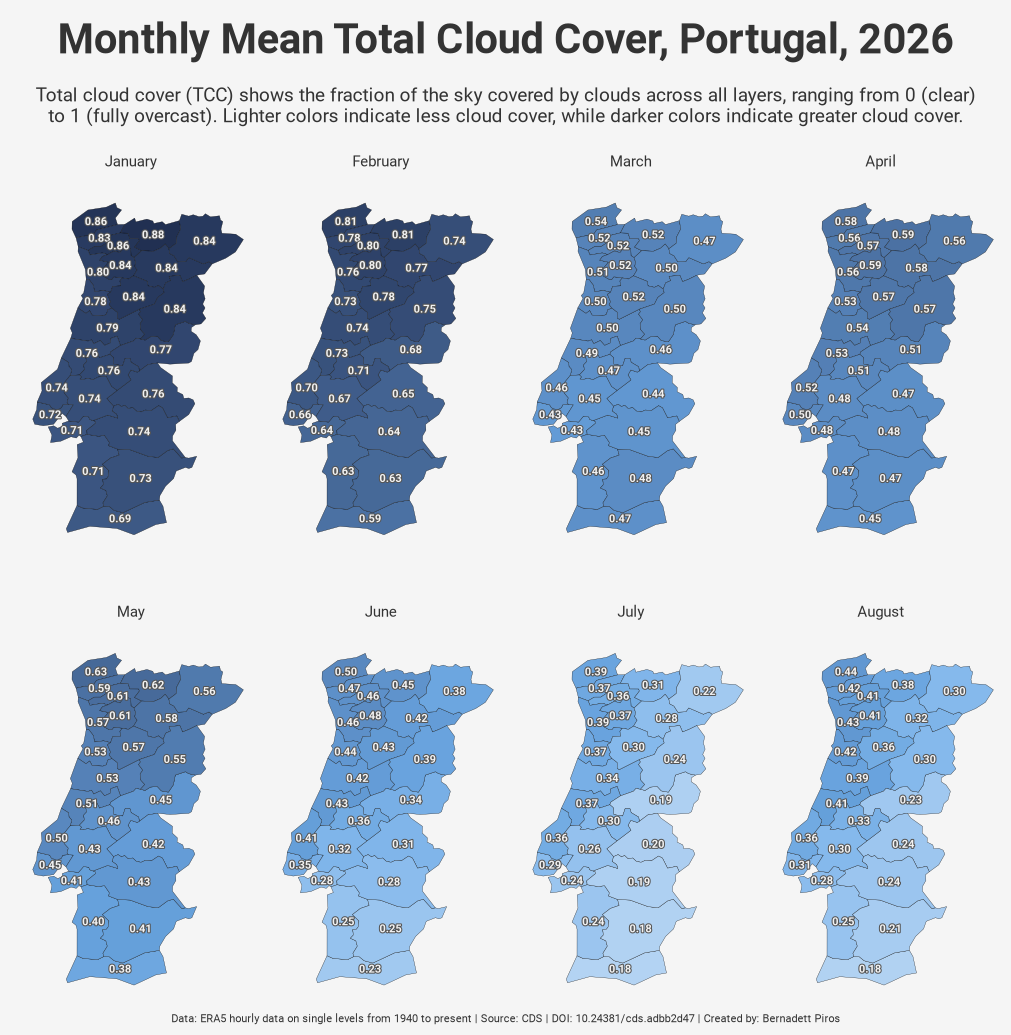

In [10]:
fig = ekp.Figure(rows=2, columns=4, figsize=(10, 9))

levels = np.arange(0, 1.1, 0.1)

h_style = ekp.styles.Style(
    colors=[
        "#f1f7fd",
        "#cde2f7",
        "#a9cdf1",
        "#83b8ec",
        "#66a1dc",
        "#5887be",
        "#4a6fa0",
        "#3c5783",
        "#2d4168",
        "#1e2c4d",
        "#17223b",
    ],
    levels = levels,
    gradients=[20] * (len(levels) - 1),  
)


for i, forecast_time in enumerate(
    reduced_data_weighted.forecast_reference_time.values
):

    monthly_data = reduced_data_weighted.sel(
        forecast_reference_time=forecast_time
    )

    nuts_month = nuts3_pt.copy()
    nuts_month["tcc"] = monthly_data["tcc"].values

    ax = fig.add_map(
        i // 4,
        i % 4,
        domain="Portugal",
    )

    choropleth =ax.choropleth(
        nuts_month,
        z="tcc",
        metadata={
            "units": "percent",
            "long_name": "Total Cloud Cover",
        },        
        labels="{tcc:0.2f}",
        style=h_style,
        ec="black",
        lw=0.2
    )

    for text in choropleth.ax.texts:
        text.set_fontsize(8)    

    month = pd.Timestamp(forecast_time).strftime("%B")

    ax.title(month)

    ax.ax.set_axis_off()

fig.title("Monthly Mean Total Cloud Cover, Portugal, 2026", y=1.15, fontsize=30, weight="bold")

fig.fig.text(0.5, 1.025, s=title, fontsize=14, ha="center")

fig.fig.text(0.5, 0.025, s=caption, fontsize=8, ha="center")

fig.fig.set_facecolor("whitesmoke")

fig.show()

#fig.save("tcc.png", dpi=300)